## how to use this notebook

this notebook is a reusable pipeline step that filters a raw legislative text dataset down to
social-policy relevant documents using cosine similarity between document title embeddings and
policy-field seed descriptions.

**to process a new dataset:**

1. set `INPUT_FILE` in the **configuration** cell below to your raw `.json` file
   (format: a JSON list of objects, each with at least a `"title"` field)
2. set `OUTPUT_DIR` to the folder where results should be saved
3. set `OUTPUT_PREFIX` to a short label for your run — used to name output files (e.g. `"germany_cov"`)
4. run the scouting section (§1) and the score-distribution plot (§2) to inspect your data
5. adjust `AUTO_THRESHOLD` and `BORDERLINE_LOW` based on the score distribution:
   - documents scoring ≥ `AUTO_THRESHOLD` → auto-accepted (high confidence)
   - documents scoring ≥ `BORDERLINE_LOW` but < `AUTO_THRESHOLD` → manual triage via `step4_process_triage_germany_borderline.py`
   - documents scoring below `BORDERLINE_LOW` → discarded
6. run the saving section (§2.2) to write the output files

**seed descriptions** (imported from `step2_process_ger_seed_descriptions.py`) define the
policy domain you are filtering for. to filter for a different domain, replace or extend
`ALL_SEEDS` in that file.

**outputs saved to `OUTPUT_DIR`:**
- `{OUTPUT_PREFIX}_auto_accepted.json` — high-confidence matches, ready for LLM classification
- `{OUTPUT_PREFIX}_borderline_candidates.json` — borderline matches, needs manual triage

# processing german bgbl raw data



In [3]:
# pip installs:
##pip install sentence-transformers

#imports:

##imports for reading data
import json

##imports for 2.1 filtering approach 1:

import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import numpy as np
from step2_process_ger_seed_descriptions import ALL_SEEDS #these are seed descriptions of social policy fields I created based on a bmas publication under "policy-tracker/data/external/bmas_soziale-sicherung-im-ueberblick.pdf"
from sklearn.metrics.pairwise import cosine_similarity

##imports to save filtered and processed raw texts

from pathlib import Path

##imports for log file

import datetime, os, stat


In [4]:
# ── CONFIGURATION — set these before running ────────────────────────────────

def _find_root(marker="CLAUDE.md"):
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / marker).exists():
            return p
    raise FileNotFoundError(f"project root not found (no {marker} above {Path.cwd()})")

PROJECT_ROOT = _find_root()

INPUT_FILE    = PROJECT_ROOT / "data/raw/germany/bgbl1_2019-2022_20260408.json"
OUTPUT_DIR    = PROJECT_ROOT / "data/processed/germany"
OUTPUT_PREFIX = "germany_cov_2019-2022"   # prefix for output filenames (IMPORTANT!)


print(f"Project root: {PROJECT_ROOT}")

# ────────────────────────────────────────────────────────────────────────────

Project root: s:\stbuchho\crises_and_welfare_states\policy-tracker


## 1. scouting raw data

In [8]:
with open(INPUT_FILE, "r", encoding="utf-8") as file:
    data = json.load(file)

entries = data if isinstance(data, list) else list(data.values())
for i, entry in enumerate(entries[:10]):
    print(f"--- Entry {i+1} ---")
    print(json.dumps(entry, ensure_ascii=False, indent=2))

--- Entry 1 ---
{
  "id": "bgbl1-2019-52-1",
  "year": 2019,
  "issue_number": 52,
  "order_in_issue": 1,
  "title": "Gesetz zur Einführung einer Pflicht zur Mitteilung grenzüberschreitender Steuergestaltungen",
  "doc_type": "Gesetz",
  "date_published": "2019-12-30T00:00:00Z",
  "date_law": "2019-12-21T00:00:00Z",
  "bgbl_page": 2875,
  "pdf_page": 3,
  "num_pages": 11,
  "url_web": "https://offenegesetze.de/veroeffentlichung/bgbl1/2019/52#page=3",
  "url_api": "https://api.offenegesetze.de/v1/veroeffentlichung/bgbl1-2019-52-1/",
  "url_pdf": "https://media.offenegesetze.de/bgbl1/2019/bgbl1_2019_52.pdf#page=3",
  "full_text": "Bundesgesetzblatt Jahrgang 2019 Teil I Nr. 52, ausgegeben zu Bonn am 30. Dezember 2019                   2875\nGesetz\nzur Einführung einer Pflicht\nzur Mitteilung grenzüberschreitender Steuergestaltungen1\nVom 21. Dezember 2019\nDer Bundestag hat mit Zustimmung des Bundes-                       dem Bundeszentralamt für Steuern nach Maßgabe\nrates das folgende 

## 2. filtering

goal: this section filters social-policy relevant titles from the entire entire retrieved body of raw legal text data (for Germany: Gesetze, REchtsverordnungen, Bekanntmachungen). 

approach: it utilizes cosine similarities between the embeddings of titles of these documents and policy-field seed descriptions that were constructed in step1_process_ger_seed_desc_covid and step2_process_ger_seed_desc.py. for the embeddings the German-suited sentence transformer "paraphrase-multilingual-mpnet-base-v2" is used.

decision: legal text documents with high cosine similarities to the seed descriptions are selected and stored.

In [9]:

#create object for transformer model
model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")

#embed seeds
seed_embeddings = model.encode(ALL_SEEDS, show_progress_bar=True)

#embed legal documents via titles
titles=[doc["title"] for doc in data]
doc_embeddings = model.encode(titles, batch_size=16, show_progress_bar=True)

#cosine similarity: for each doc, max similarity across all seeds
sim_matrix = cosine_similarity(doc_embeddings, seed_embeddings) # shape: rows are docs, columns are seeds
max_scores = sim_matrix.max(axis=1) #collapses each row to its highest value (the seed that matched the doc best)

print(f"Score range: {max_scores.min():.3f} – {max_scores.max():.3f}")
print(f"Mean: {max_scores.mean():.3f}, Median: {np.median(max_scores):.3f}")


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/101 [00:00<?, ?it/s]

Score range: 0.290 – 0.966
Mean: 0.619, Median: 0.611


interpretation score range: cosine similarity scores range from 0.373 - 0.966 -> suggests that there is a real signal to work with here for filtering


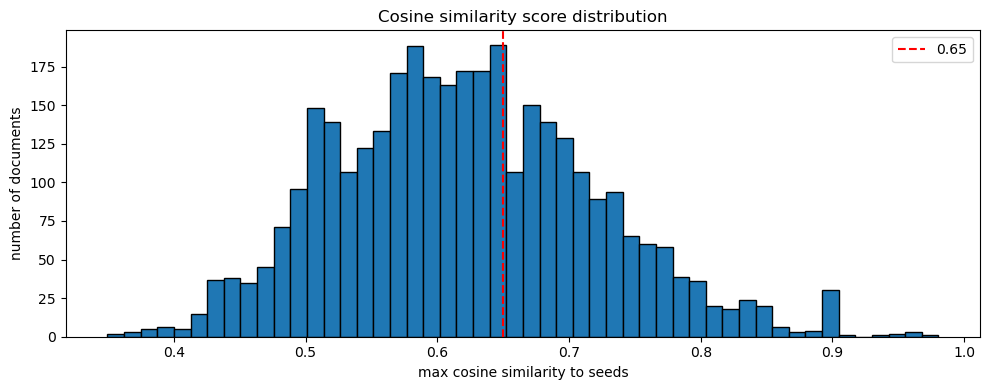

In [37]:
# distribution of cosine-similarity scores between documents and the seed descriptions

fig_scores, ax_scores = plt.subplots(figsize=(10, 4))
ax_scores.hist(max_scores, bins=50, edgecolor="black")
ax_scores.set_xlabel("max cosine similarity to seeds")
ax_scores.set_ylabel("number of documents")
ax_scores.set_title("Cosine similarity score distribution")
ax_scores.axvline(x=0.65, color="red", linestyle="--", label="0.65")
ax_scores.legend()
fig_scores.tight_layout()
plt.show()

visual investigation of the distribution of cosine similarity scores : can we identify a normal distribution for the (ideally so, because there is legislation that is social policy related (few) and such that is not (majority)? are cut-off values of scores detectable?

if no cut-off values are detectable (most likely case), then the following step creates lists of policy text titles along certain cut-offs

In [12]:
scored = sorted(zip(max_scores, data), key=lambda x: x[0], reverse=True)

print("=== TOP 10 ===")
for score, doc in scored[:30]:
    print(f"  {score:.3f}  {doc['title'][:150]}")

print("\n=== ABOVE 0.73 ===")
for score, doc in scored:
    if  score > 0.73:
        print(f"  {score:.3f}  {doc['title'][:150]}") 


print("\n=== AROUND 0.70 ===")
for score, doc in scored:
    if 0.69 < score < 0.71:
        print(f"  {score:.3f}  {doc['title'][:100]}")   


print("\n=== BOTTOM 10 ===")
for score, doc in scored[-10:]:
    print(f"  {score:.3f}  {doc['title'][:100]}")

=== TOP 10 ===
  0.966  Gesetz für Maßnahmen im Elterngeld aus Anlass der COVID-19-Pandemie
  0.949  Gesetz zu sozialen Maßnahmen zur Bekämpfung der Corona-Pandemie (Sozialschutz-Paket II)
  0.946  Verordnung zur Änderung der Kurzarbeitergeldzugangsverordnung
  0.942  Verordnung über die Bezugsdauer für das Kurzarbeitergeld (Kurzarbeitergeldbezugsdauerverordnung – KugBeV)
  0.933  Zweite Verordnung über die Bezugsdauer für das Kurzarbeitergeld (Zweite Kurzarbeitergeldbezugsdauerverordnung – 2. KugBeV)
  0.932  Gesetz zur Umsetzung steuerlicher Hilfsmaßnahmen zur Bewältigung der Corona-Krise (Corona-Steuerhilfegesetz)
  0.918  Viertes Gesetz zur Umsetzung steuerlicher Hilfsmaßnahmen zur Bewältigung der Corona-Krise (Viertes Corona-Steuerhilfegesetz)
  0.915  Erste Verordnung zur Änderung der Kurzarbeitergeldverordnung
  0.910  Zweite Verordnung zur Änderung der Kurzarbeitergeldverordnung
  0.908  Vierte Verordnung zur Änderung der Kurzarbeitergeldverordnung
  0.904  Zweites Gesetz zur Ä

results: the visual inspection serves the identification of an auto-threshold above which policy documents are auto-accepted and a borderline-low below which policies are auto-rejected. between those threshholds, a human manual triage is conducted in step4


In [14]:
# ── CONFIGURATION — set these before running ────────────────────────────────
AUTO_THRESHOLD = 0.836   # cosine similarity >= this → auto-accepted
BORDERLINE_LOW = 0.73    # cosine similarity >= this but < AUTO_THRESHOLD → manual triage


## 2.2 saving the final .json

this section saves two output files. thresholds are set in the configuration cell above — adjust them
based on the score distribution plots in the previous section.

- documents scoring ≥ `AUTO_THRESHOLD` are written to `{OUTPUT_PREFIX}_auto_accepted.json`
- documents scoring ≥ `BORDERLINE_LOW` but below `AUTO_THRESHOLD` are written to `{OUTPUT_PREFIX}_borderline_candidates.json` for individual manual inspection with the triage tool in `step4_process_triage_germany_borderline.py`

In [15]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

auto_accepted = []
borderline = []

for score, doc in scored:
    entry = {**doc, "similarity_score": float(score)}
    if score >= AUTO_THRESHOLD:
        auto_accepted.append(entry)
    elif score >= BORDERLINE_LOW:
        borderline.append(entry)

print(f"Auto-accepted (>= {AUTO_THRESHOLD}):                {len(auto_accepted)}")
print(f"Borderline ({BORDERLINE_LOW}–{AUTO_THRESHOLD - 0.001:.3f}, needs manual triage): {len(borderline)}")
print(f"Below threshold (< {BORDERLINE_LOW}):               {len(scored) - len(auto_accepted) - len(borderline)}")

auto_path       = OUTPUT_DIR / f"{OUTPUT_PREFIX}_auto_accepted.json"
borderline_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_borderline_candidates.json"

auto_path.write_text(json.dumps(auto_accepted, ensure_ascii=False, indent=2), encoding="utf-8")
borderline_path.write_text(json.dumps(borderline, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"\nSaved: {auto_path}")
print(f"Saved: {borderline_path}")
print("\nNext: run step4_process_triage_germany_borderline.py to review borderline cases.")

Auto-accepted (>= 0.836):                45
Borderline (0.73–0.835, needs manual triage): 154
Below threshold (< 0.73):               1413

Saved: s:\stbuchho\crises_and_welfare_states\policy-tracker\data\processed\germany\germany_cov_2019-2022_auto_accepted.json
Saved: s:\stbuchho\crises_and_welfare_states\policy-tracker\data\processed\germany\germany_cov_2019-2022_borderline_candidates.json

Next: run step4_process_triage_germany_borderline.py to review borderline cases.


## 3. run log

saves a read-only markdown log to `data/processed/run/{country}/runlogs_from_step3/`. the filename encodes the dataset and run date so each run produces a distinct, non-overwritable record.

In [17]:


run_date   = datetime.date.today().isoformat()
input_stem = Path(INPUT_FILE).stem
log_dir    = OUTPUT_DIR / "runlogs_from_step3"
log_dir.mkdir(parents=True, exist_ok=True)

log_stem = f"filter_runlog_{OUTPUT_PREFIX}_{input_stem}_{run_date}"
log_path = log_dir / f"{log_stem}.md"
png_name = f"{log_stem}_scores.png"
png_path = log_dir / png_name

# strip read-only if files exist from a same-day re-run
for p in (png_path, log_path):
    if p.exists():
        os.chmod(p, stat.S_IWRITE)

fig_scores.savefig(png_path, dpi=150, bbox_inches="tight")
os.chmod(png_path, stat.S_IREAD | stat.S_IRGRP | stat.S_IROTH)

content = f"""# filter run log

| | |
|---|---|
| date | {run_date} |
| input file | `{INPUT_FILE}` |
| output dir | `{OUTPUT_DIR}` |
| output prefix | `{OUTPUT_PREFIX}` |

## configuration

| parameter | value |
|---|---|
| AUTO_THRESHOLD | {AUTO_THRESHOLD} |
| BORDERLINE_LOW | {BORDERLINE_LOW} |

## score distribution

| metric | value |
|---|---|
| min | {max_scores.min():.3f} |
| max | {max_scores.max():.3f} |
| mean | {max_scores.mean():.3f} |
| median | {np.median(max_scores):.3f} |

![score distribution]({png_name})

## filtering results

| category | n |
|---|---|
| auto-accepted (>= {AUTO_THRESHOLD}) | {len(auto_accepted)} |
| borderline ({BORDERLINE_LOW}–{AUTO_THRESHOLD - 0.001:.3f}) | {len(borderline)} |
| below threshold (< {BORDERLINE_LOW}) | {len(scored) - len(auto_accepted) - len(borderline)} |
| total | {len(scored)} |

## output files

- `{auto_path}`
- `{borderline_path}`
"""

log_path.write_text(content, encoding="utf-8")
os.chmod(log_path, stat.S_IREAD | stat.S_IRGRP | stat.S_IROTH)
print(f"Run log saved (read-only): {log_path}")
print(f"Score plot saved (read-only): {png_path}")

NameError: name 'fig_scores' is not defined